# **Generazione e riconoscimento di tonalità DTMF**

### **Import delle librerie**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft
import os
from src.DTMF_implementation import (
    plot_all_tones_grid,
    dialNumber,
    plot_and_save_sequence,
    plot_spectrum,
    recNumber,
    recSequence,
    dialNumber_pauses,
    detect_sequence_pauses
)
from src.experiments.duration import run_duration_experiments
from src.experiments.noise import run_noise_experiments
from src.experiments.sampling import run_sampling_experiments
from src.improvements.denoising import run_denoising_experiments
from src.improvements.zero_padding import run_zeropadding_experiments

### **Configurazione struttura cartelle di salvataggio figure + file .wav**

In [2]:
PLOTS_BASE = "Plots"

# Sottocartelle principali
PLOTS_IMPLEMENTATION = os.path.join(PLOTS_BASE, "DTMF_implementation")
PLOTS_EXPERIMENTS = os.path.join(PLOTS_BASE, "experiments")
PLOTS_IMPROVEMENTS = os.path.join(PLOTS_BASE, "improvements")

# Sottocartelle esperimenti
PLOTS_NOISE = os.path.join(PLOTS_EXPERIMENTS, "noise")
PLOTS_DURATION = os.path.join(PLOTS_EXPERIMENTS, "duration")
PLOTS_SAMPLING = os.path.join(PLOTS_EXPERIMENTS, "sampling")

# Sottocartelle miglioramenti
PLOTS_DENOISING = os.path.join(PLOTS_IMPROVEMENTS, "denoising")
PLOTS_ZEROPADDING = os.path.join(PLOTS_IMPROVEMENTS, "zero_padding")

# Cartelle per file audio WAV
AUDIO_BASE = "Audio"
AUDIO_TONES = os.path.join(AUDIO_BASE, "tones")
AUDIO_SEQUENCES = os.path.join(AUDIO_BASE, "sequences")

# Creazione di tutte le cartelle
folders = [
    PLOTS_BASE,
    PLOTS_IMPLEMENTATION,
    PLOTS_EXPERIMENTS,
    PLOTS_IMPROVEMENTS,
    PLOTS_NOISE,
    PLOTS_DURATION,
    PLOTS_SAMPLING,
    PLOTS_DENOISING,
    PLOTS_ZEROPADDING,
    AUDIO_BASE,
    AUDIO_TONES,
    AUDIO_SEQUENCES
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

## **1. Implementazione DTMF**

### **1.1 Creazione del dizionario**

In [3]:
# Definizione delle frequenze DTMF (Standard ETSI)
F1 = np.array([697, 770, 852, 941])      # Frequenze basse (righe)
F2 = np.array([1209, 1336, 1477, 1633])  # Frequenze alte (colonne)

# Definizione del dizionario dei toni
tones = {
    '1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3),
    '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3),
    '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3),
    '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)
}

# Visualizzazione del dizionario
print("Dizionario toni DTMF:")
print(tones)

# Visualizzazione matrice frequenze
print("\nMatrice frequenze DTMF:")
print(f"{'':>5} | {F2[0]:>6} Hz | {F2[1]:>6} Hz | {F2[2]:>6} Hz | {F2[3]:>6} Hz")
print("-" * 60)
for i, f1 in enumerate(F1):
    row = [key for key, (r, c) in tones.items() if r == i]
    print(f"{f1:>3} Hz | {row[0]:>8} | {row[1]:>8} | {row[2]:>8} | {row[3]:>8}")

Dizionario toni DTMF:
{'1': (0, 0), '2': (0, 1), '3': (0, 2), 'A': (0, 3), '4': (1, 0), '5': (1, 1), '6': (1, 2), 'B': (1, 3), '7': (2, 0), '8': (2, 1), '9': (2, 2), 'C': (2, 3), '*': (3, 0), '0': (3, 1), '#': (3, 2), 'D': (3, 3)}

Matrice frequenze DTMF:
      |   1209 Hz |   1336 Hz |   1477 Hz |   1633 Hz
------------------------------------------------------------
697 Hz |        1 |        2 |        3 |        A
770 Hz |        4 |        5 |        6 |        B
852 Hz |        7 |        8 |        9 |        C
941 Hz |        * |        0 |        # |        D


#### **Parametri di campionamento globali**

In [4]:
Fs = 8000          # Frequenza di campionamento [Hz]
toneDuration = 0.15  # Durata standard dei toni [s]

print(f"Frequenza di campionamento: {Fs} Hz")
print(f"Durata toni: {toneDuration} s")
print(f"Campioni per tono: {int(Fs * toneDuration)}")

Frequenza di campionamento: 8000 Hz
Durata toni: 0.15 s
Campioni per tono: 1200


### **1.2 Esempio applicativo**

#### **Visualizzazione di tutti i toni DTMF nel dominio del tempo e della frequenza**

In [ ]:
plot_all_tones_grid(duration=toneDuration, Fs=Fs, plot_folder=PLOTS_IMPLEMENTATION)

#### **Generazione e visualizzazione della sequenza '3456318060'**

In [ ]:
# Generazione della sequenza
sequenza = "3456318060"
full_signal = dialNumber(sequenza, toneDuration, Fs)

# Visualizzazione e salvataggio nel dominio del tempo
plot_and_save_sequence(
    full_signal, 
    Fs, 
    filename="sequenza.wav",
    plot_filename="sequenza.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    audio_folder=AUDIO_SEQUENCES
)

# Visualizzazione e salvataggio dello spettro
plot_spectrum(
    full_signal, 
    Fs, 
    plot_filename="spettro_sequenza.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    annotate_dtmf=True,
    sequence='3456318060'
)

#### **Riconoscimento della sequenza**

In [ ]:
detected = recSequence(full_signal, toneDuration, Fs)

print(f"Sequenza originale:    {list(sequenza)}")
print(f"Sequenza riconosciuta: {detected}")

# Verifica correttezza
if detected == list(sequenza):
    print("Riconoscimento corretto!")
else:
    print("Errore nel riconoscimento")

#### **Inserimento di pause tra un tono e l'altro**

In [ ]:
# Generazione sequenza con pause
pauseDuration = 0.05
full_signal_pauses = dialNumber_pauses(sequenza, toneDuration, Fs, pauseDuration)

# Visualizzazione e salvataggio nel dominio del tempo
plot_and_save_sequence(
    full_signal_pauses, 
    Fs, 
    filename="sequenza_pause.wav",
    plot_filename="sequenza_pause.pdf",
    plot_folder=PLOTS_IMPLEMENTATION,
    audio_folder=AUDIO_SEQUENCES
)

# Visualizzazione e salvataggio dello spettro
plot_spectrum(
    full_signal_pauses, 
    Fs, 
    plot_filename="spettro_sequenza_pause.pdf",
    plot_folder=PLOTS_IMPLEMENTATION
)

# Riconoscimento sequenza con pause
detected_pauses = detect_sequence_pauses(
    full_signal_pauses, 
    toneDuration, 
    pauseDuration, 
    Fs, 
    silence_threshold=0.05
)

print(f"Sequenza originale:    {list(sequenza)}")
print(f"Sequenza riconosciuta: {detected_pauses}")

# Verifica correttezza
if detected_pauses == list(sequenza):
    print("Riconoscimento corretto!")
else:
    print("Errore nel riconoscimento")

#### **Confronto spettri: con e senza pause**

In [ ]:
# Lunghezze originali
N_no = len(full_signal)
N_pa = len(full_signal_pauses)

# Lunghezza massima
N = max(N_no, N_pa)

# Padding per allineare le lunghezze
sig_no = np.pad(full_signal, (0, N - N_no), mode='constant')
sig_pa = np.pad(full_signal_pauses, (0, N - N_pa), mode='constant')

# FFT
X_no = fftshift(fft(sig_no))
X_pa = fftshift(fft(sig_pa))

# Ampiezze normalizzate
X_no_norm = np.abs(X_no) / np.max(np.abs(X_no))
X_pa_norm = np.abs(X_pa) / np.max(np.abs(X_pa))

# Asse delle frequenze
freqs = np.linspace(-Fs/2, Fs/2, N, endpoint=False)

# Plot overlay
plt.figure(figsize=(12, 5))
plt.plot(freqs, X_no_norm, label="Senza pause", linewidth=1.5)
plt.plot(freqs, X_pa_norm, label="Con pause", alpha=0.7, linewidth=1.5)
plt.xlim(0, 2500)
plt.xlabel("Frequenza [Hz]", fontsize=12)
plt.ylabel("Ampiezza normalizzata", fontsize=12)
plt.title("Confronto spettri: sequenza DTMF con e senza pause", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Salvataggio
os.makedirs(PLOTS_IMPLEMENTATION, exist_ok=True)
plot_path = os.path.join(PLOTS_IMPLEMENTATION, "spettro_overlay_pause.pdf")
plt.tight_layout()
plt.savefig(plot_path, format='pdf', bbox_inches='tight')
print(f"Plot salvato: {plot_path}")

plt.show()
plt.close()

## **2. Esperimenti e metodologia**

In [5]:
np.random.seed(42)

### **2.1 Variazione della durata del tono**

In [ ]:
durations = np.round(np.logspace(np.log10(0.001), np.log10(0.2), 12), 4).tolist()

In [ ]:
# Esegui tutti gli esperimenti sulla durata
results_duration = run_duration_experiments(
    durations=durations,
    Fs=Fs,
    n_sequences=100,
    n_trials=50,
    tone_char='9',
    seq="3456318060",
    plot_folder=PLOTS_DURATION
)

### **2.2 Aggiunta di rumore al segnale**

In [ ]:
# Esegui tutti gli esperimenti sul rumore
results = run_noise_experiments(
    sigmas=[0, 0.05, 0.2, 0.5, 1, 2, 3, 4, 5, 6],
    durations=durations,
    Fs=8000,
    n_sequences=1000,
    n_trials=50,
    plot_folder=PLOTS_NOISE
)

### **2.3 Variazione della frequenza di campionamento**

In [ ]:
results = run_sampling_experiments(
    Fs_list=[2000, 3000, 3266, 4000, 8000, 16000],
    duration=0.15,
    n_sequences=100,
    plot_folder=PLOTS_SAMPLING
)

## **3. Miglioramenti dell'algoritmo**

### **3.1 Zero-padding**

In [ ]:
durations_fine = [
    0.003,
    0.004,
    0.005,
    0.006,
    0.007,
    0.008,
    0.009,
    0.010,
    0.012,
    0.015,
    0.020,
]

In [ ]:
results = run_zeropadding_experiments(
    durations=durations_fine,
    M_factors=[1, 2, 4, 8],
    Fs=8000,
    n_sequences=100,
    plot_folder=PLOTS_ZEROPADDING
)

### **3.2 Filtraggio segnale rumoroso**

ESPERIMENTI: TECNICHE DI DENOISING

1. Generazione confronti visuali per filtri...
Plot salvato: Plots/improvements/denoising/denoising_moving_average.pdf


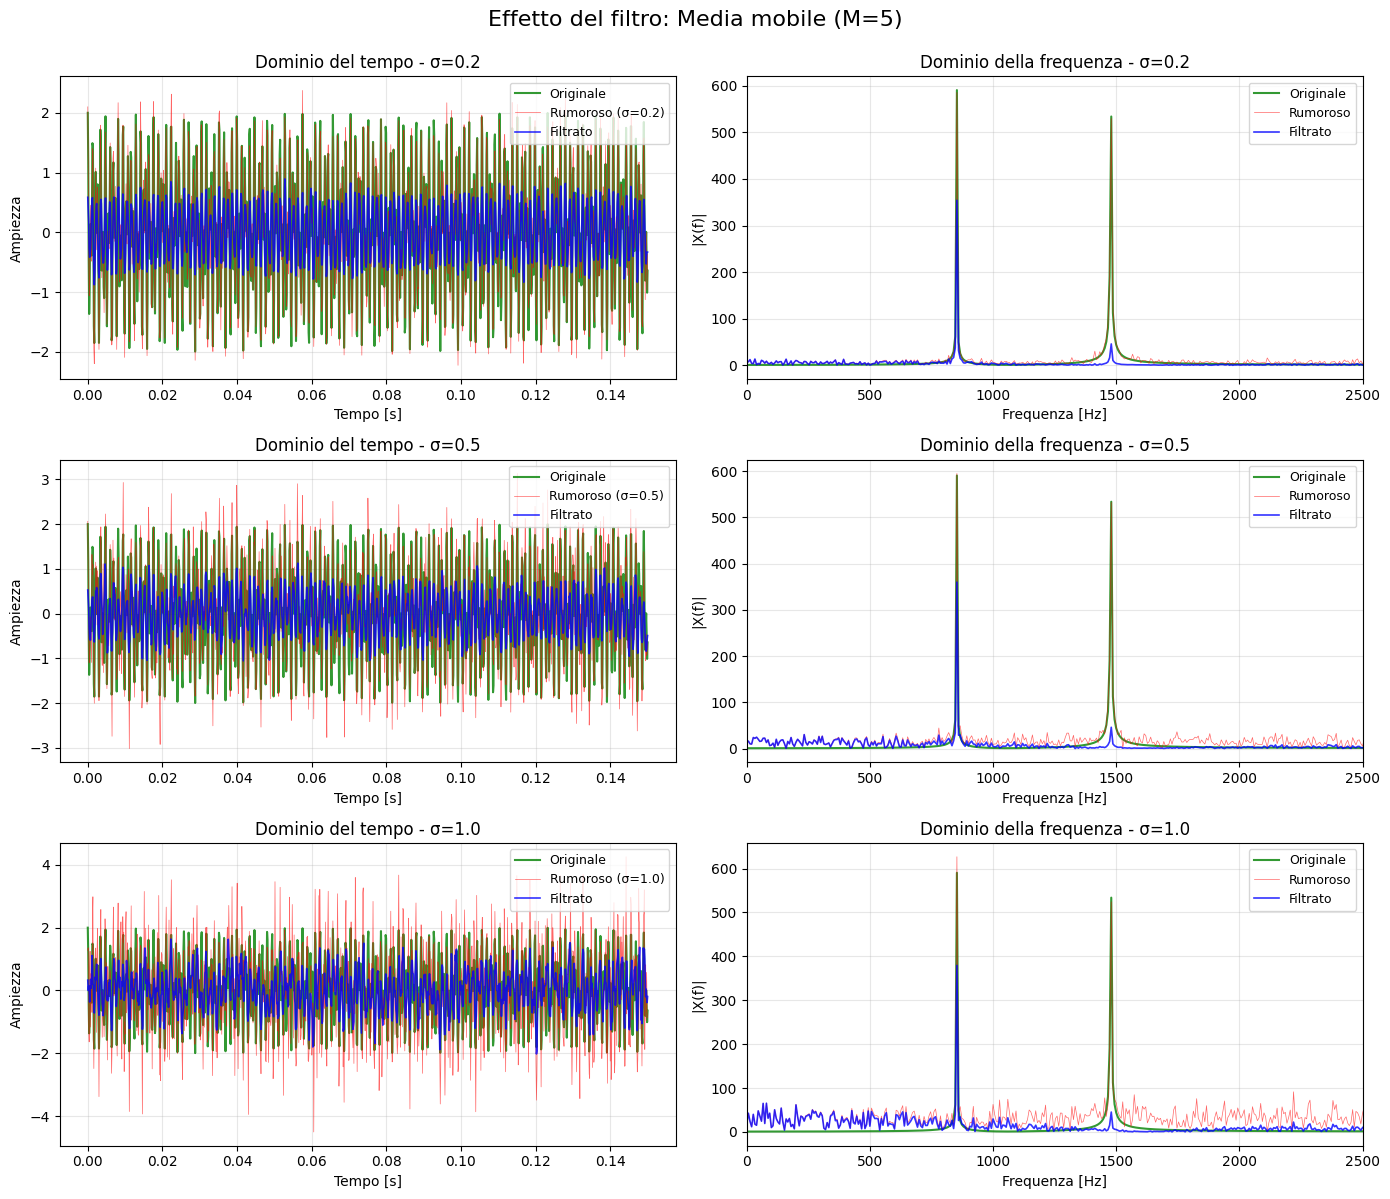

Plot salvato: Plots/improvements/denoising/denoising_leaky_integrator.pdf


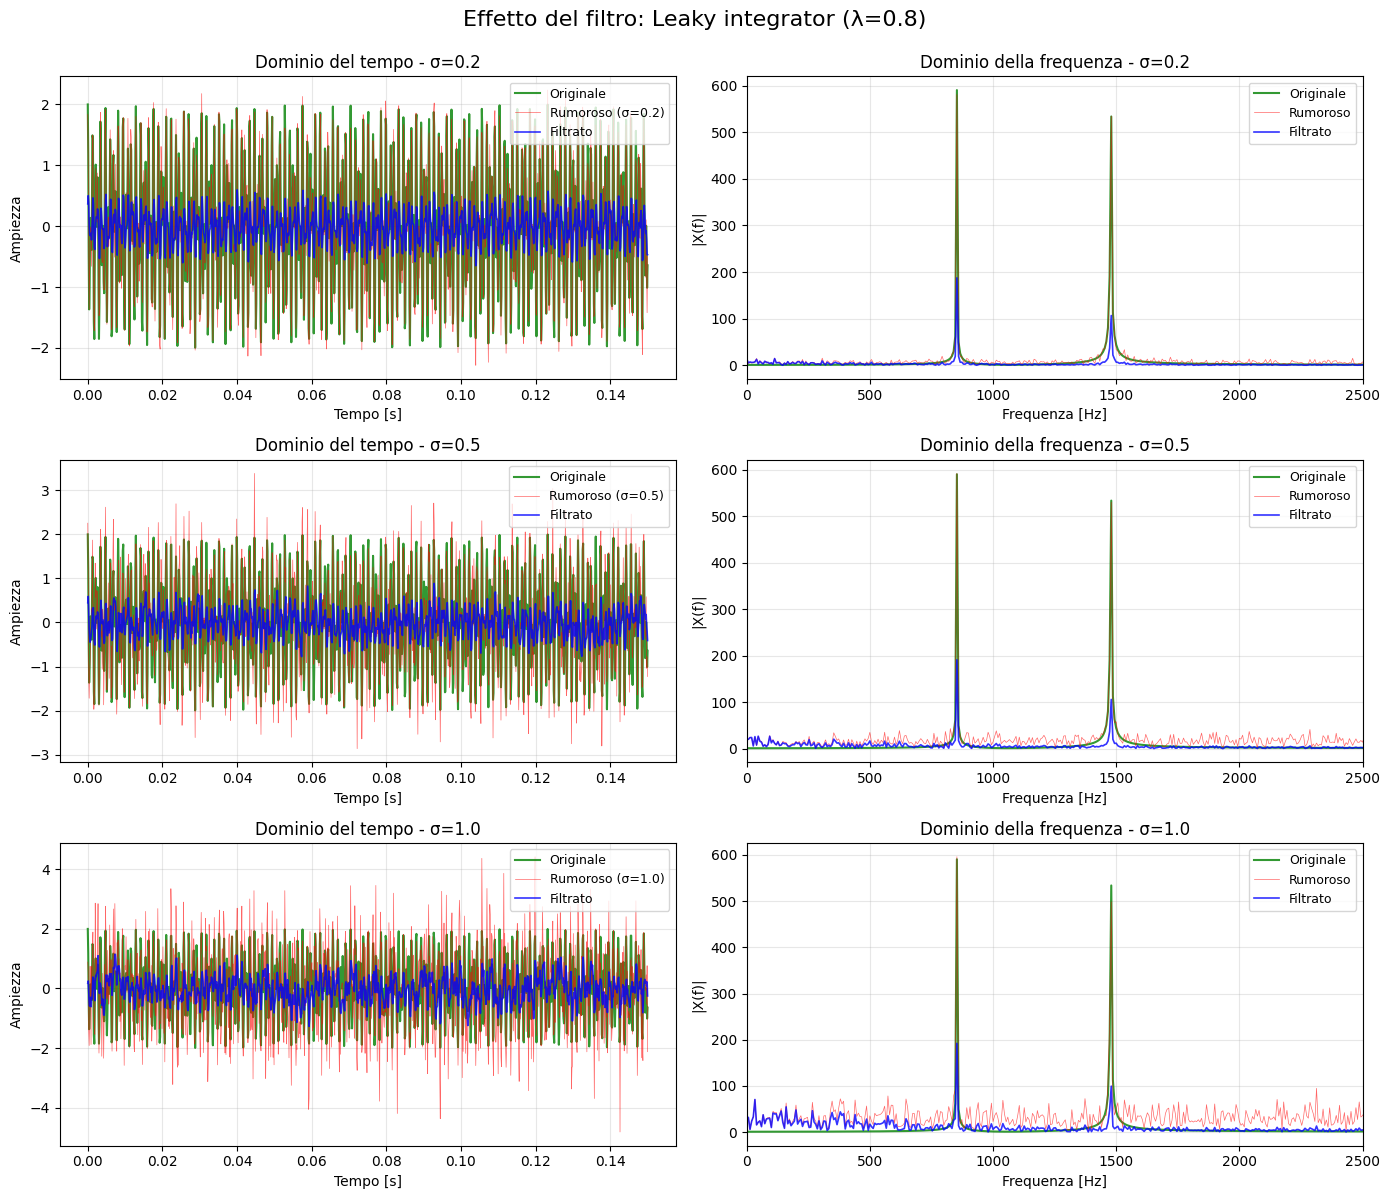

Plot salvato: Plots/improvements/denoising/denoising_bandpass.pdf


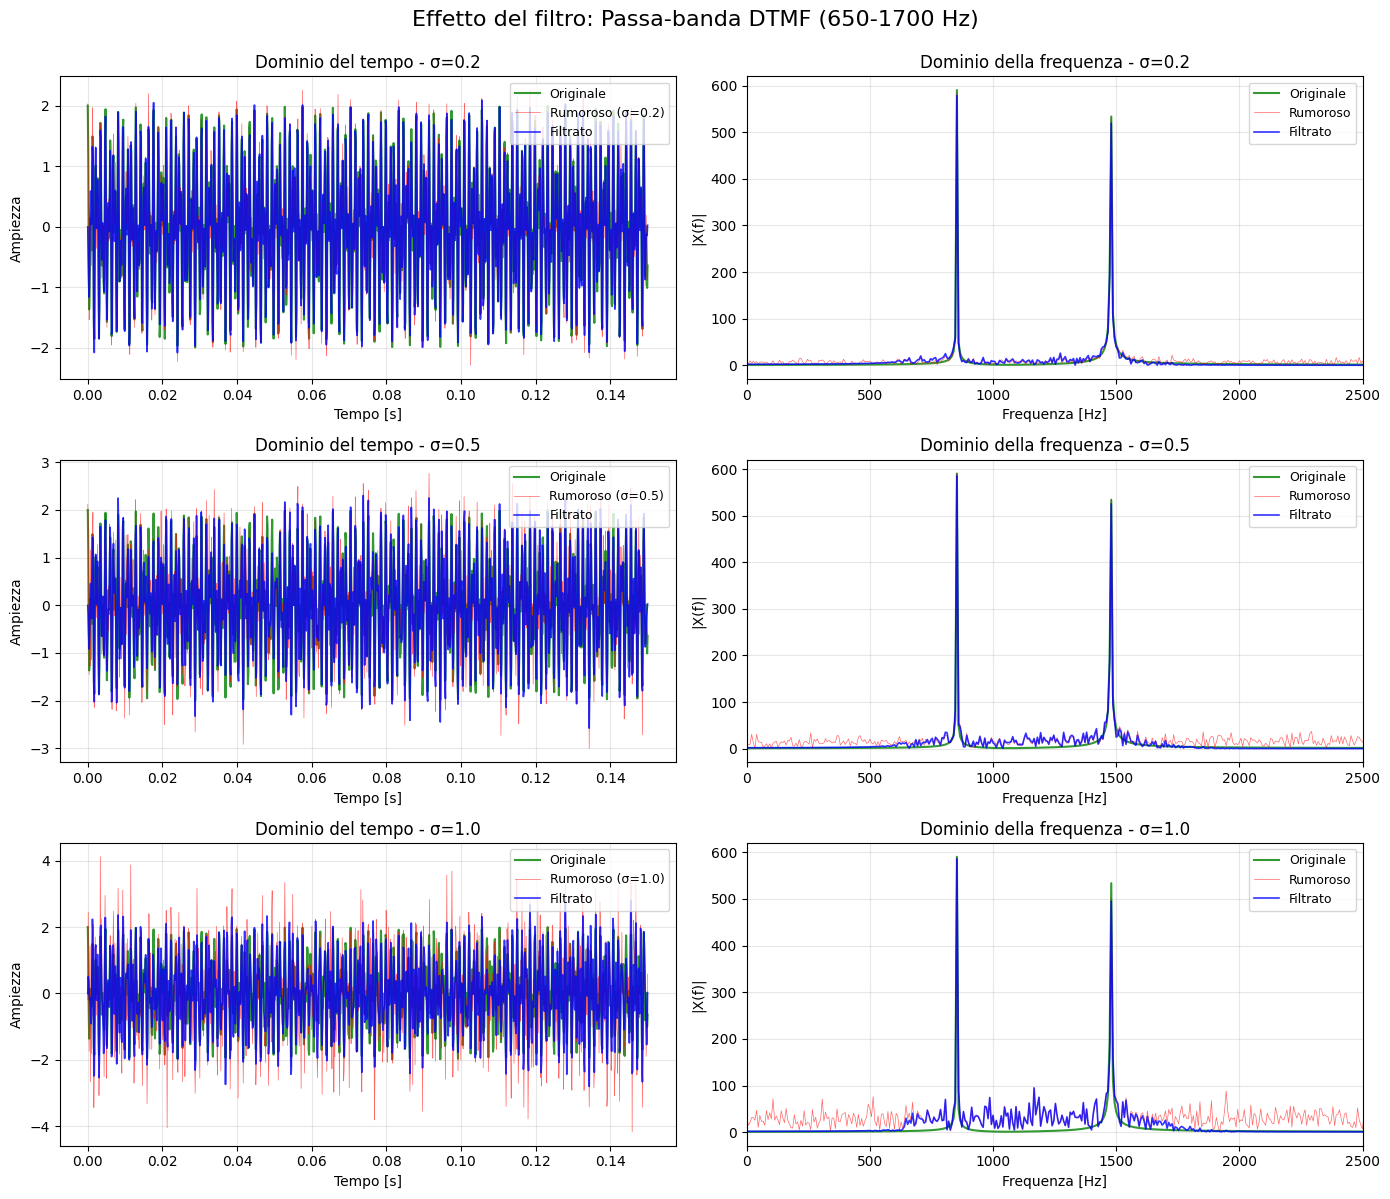

ESPERIMENTI: TECNICHE DI DENOISING

Testing sigma = 0
  no_filter: 100.0%
  moving_average: 100.0%
  leaky_integrator: 100.0%
  bandpass: 100.0%

Testing sigma = 0.5
  no_filter: 100.0%
  moving_average: 98.9%
  leaky_integrator: 100.0%
  bandpass: 100.0%

Testing sigma = 1
  no_filter: 100.0%
  moving_average: 48.3%
  leaky_integrator: 100.0%
  bandpass: 100.0%

Testing sigma = 2
  no_filter: 100.0%
  moving_average: 9.8%
  leaky_integrator: 100.0%
  bandpass: 99.9%

Testing sigma = 3
  no_filter: 92.8%
  moving_average: 3.2%
  leaky_integrator: 93.6%
  bandpass: 94.7%

Testing sigma = 4
  no_filter: 58.2%
  moving_average: 0.9%
  leaky_integrator: 66.2%
  bandpass: 63.4%
Grafico salvato: Plots/improvements/denoising/denoising_comparison.pdf


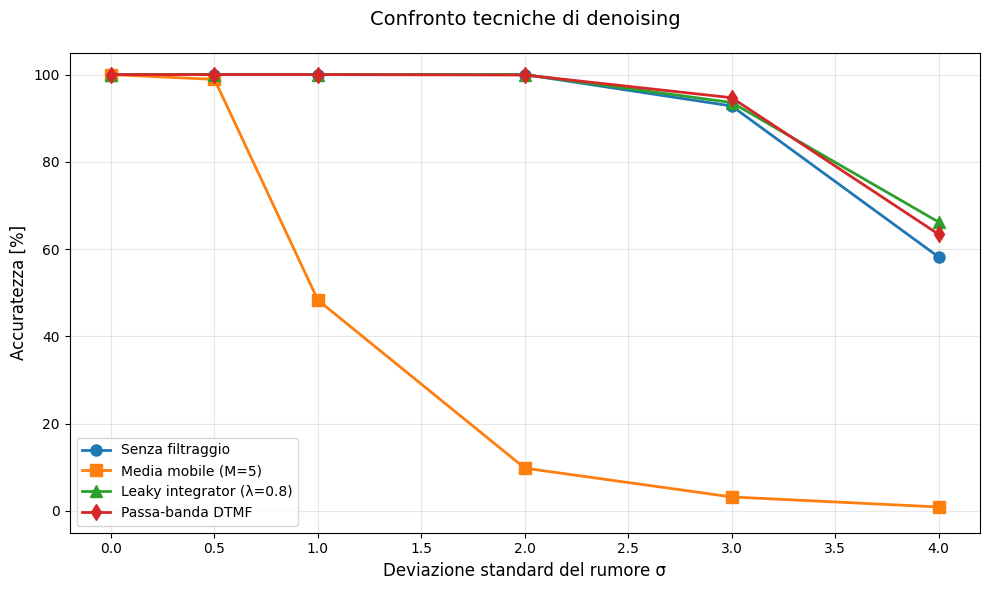


TABELLA RISULTATI
σ        No filter    Media mobile    Leaky        Passa-banda 
----------------------------------------------------------------------
0.00     100.0        100.0           100.0        100.0       
0.50     100.0        98.9            100.0        100.0       
1.00     100.0        48.3            100.0        100.0       
2.00     100.0        9.8             100.0        99.9        
3.00     92.8         3.2             93.6         94.7        
4.00     58.2         0.9             66.2         63.4        

Risultati salvati in: Plots/improvements/denoising/


In [6]:
results = run_denoising_experiments(
    sigmas=[0, 0.5, 1, 2, 3, 4],
    duration=0.15,
    Fs=8000,
    tone_char='9',
    n_sequences=1000,
    sigmas_visual=[0.2, 0.5, 1.0],
    plot_folder=PLOTS_DENOISING
)